In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
import tensorflow as tf

In [2]:
import os

DATASET_DIRECTORY = './Cat_Dog'
root = os.path.join(DATASET_DIRECTORY)
print(f"{' and '.join(os.listdir(DATASET_DIRECTORY))} Folders Exist")

TRAIN_DIRECTORY = os.path.join(root, 'train')
TEST_DIRECTORY = os.path.join(root, 'test')

split_to_directory = {
    'train': TRAIN_DIRECTORY,
    'test': TEST_DIRECTORY
}
species = np.array(['cats', 'dogs'])
splits = np.array(['train', 'test'])

for split in splits:
    split_folder = split_to_directory[split]
    print(f"{split.upper()} has {len( os.listdir(split_folder) )} files")
    
    for animal in species:
        animal_folder = os.path.join(split_folder, animal)
        print(f"{split.upper()} 's {animal} has {len( os.listdir(animal_folder) )} files")
        

test and train Folders Exist
TRAIN has 2 files
TRAIN 's cats has 279 files
TRAIN 's dogs has 278 files
TEST has 2 files
TEST 's cats has 70 files
TEST 's dogs has 70 files


In [3]:
def validate_images(root):

    X = []
    y = []
    
    for subdir, dirs, files in os.walk(root):
        for file in files:
            file_path = os.path.join(subdir, file)
            try:
                animal = 'cat' if file_path.find('cats') != -1 else 'dog' # works on binary only
                img = tf.io.read_file(file_path)
                img = tf.io.decode_image(img, channels=3, expand_animations=False)
                img = tf.image.resize(img, [150, 150])
                X.append(img.numpy())
                y.append(animal)
            except Exception as e:
                print(f"{file_path} is corrupted")  
                # os.remove(file_path}

    
    return np.array(X), np.array(y)


X_train, y_train = validate_images(split_to_directory['train'])
X_test, y_test = validate_images(split_to_directory['test'])

X_train.shape, y_train.shape

((557, 150, 150, 3), (557,))

In [4]:
# Rescaling and Encoding
X_train = X_train / 255.0
X_test = X_test / 255.0

# Label Encoder for 0 and 1 in 1 sigmoid node
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

y_train = le.fit_transform(y_train)
y_test = le.fit_transform(y_test)

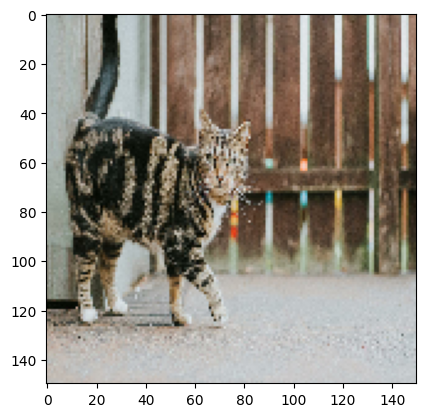

In [5]:
image = X_train[0]

plt.imshow(image)
plt.show()

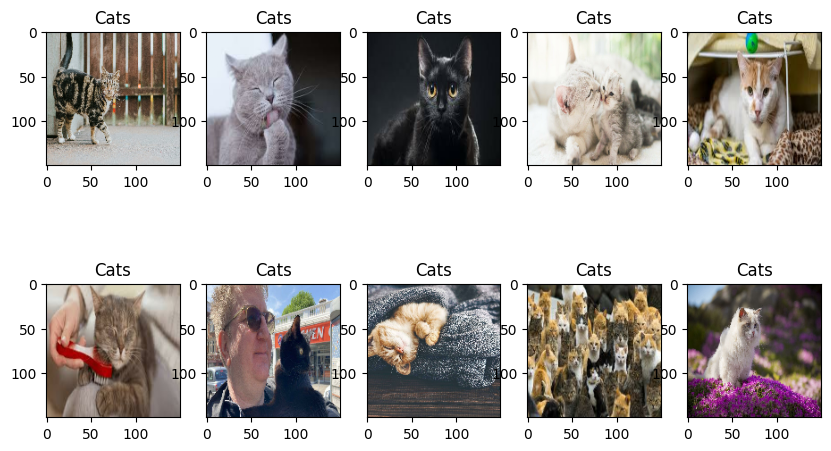

In [6]:
plt.figure(figsize=(10, 6))

for index in range(10):
    plt.subplot(2, 5, index+1)
    plt.imshow(X_train[index])
    plt.title(f"{species[ y_train[index] ].title()}")

plt.show()

In [7]:
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Input, Dense, Flatten, Conv2D, MaxPooling2D

model = Sequential([
    Input(shape=(150, 150, 3)),
    Conv2D(150, 7),
    MaxPooling2D((5, 5)),

    Flatten(),
    Dense(128, activation="relu"),
    Dense(1, activation="sigmoid")
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 144, 144, 150)  │        22,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 28, 28, 150)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 117600)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    15,052,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,075,257 (57.51 MB)

 Trainable params: 15,075,257 (57.51 MB)

 Non-trainable params: 0 (0.00 B)

In [8]:
from tensorflow.keras.optimizers import SGD
optimizer = SGD(learning_rate=0.01)

model.compile(
    optimizer= optimizer,
    metrics=['accuracy'],
    loss=tf.keras.losses.BinaryCrossentropy
)

history = model.fit(X_train, y_train, epochs=20, validation_split=0.2)

Epoch 1/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 49s 3s/step - accuracy: 0.6000 - loss: 0.6864 - val_accuracy: 0.0179 - val_loss: 0.7442
Epoch 2/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 45s 3s/step - accuracy: 0.6270 - loss: 0.6728 - val_accuracy: 0.0000e+00 - val_loss: 0.8203
Epoch 3/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 50s 4s/step - accuracy: 0.6270 - loss: 0.6581 - val_accuracy: 0.5714 - val_loss: 0.6905
Epoch 4/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 47s 3s/step - accuracy: 0.6022 - loss: 0.6564 - val_accuracy: 0.0000e+00 - val_loss: 1.1091
Epoch 5/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 41s 3s/step - accuracy: 0.6247 - loss: 0.6640 - val_accuracy: 0.0000e+00 - val_loss: 0.9144
Epoch 6/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 46s 3s/step - accuracy: 0.6539 - loss: 0.6399 - val_accuracy: 0.0000e+00 - val_loss: 1.0193
Epoch 7/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 66s 2s/step - accuracy: 0.6494 - loss: 0.6407 - val_accuracy: 0.0179 - val_loss: 0.9509
Epoch 8/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 40s 3s/step - accuracy: 0.6472 - loss: 0.6556 - val_accuracy: 0.

In [9]:
test_loss, test_accuracy = model.evaluate(X_test, y_test)

index = model.predict(X_train[:7])
np.where(index < 0.5, 0, 1).flatten()
print(f"Predicted Class Is {species[ np.where(index < 0.5, 0, 1).flatten() ]} ")

5/5 ━━━━━━━━━━━━━━━━━━━━ 5s 1s/step - accuracy: 0.5571 - loss: 0.7193 
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 650ms/step
Predicted Class Is ['cats' 'cats' 'cats' 'cats' 'cats' 'cats' 'cats'] 


In [10]:
training_loss = history.history['loss'][-1]
training_accuracy = history.history['accuracy'][-1]

metrics = pd.DataFrame(
    data = [ [training_loss, training_accuracy], [test_loss, test_accuracy] ],
columns= ["Loss", "Accuracy"], index=["Training", "Test"] )

metrics

,Loss,Accuracy
Training,0.585491,0.719101
Test,0.719282,0.557143
